In [ ]:
import pandas as pd
import numpy as np  
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC, SVR
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.model_selection import learning_curve

In [100]:
data = pd.read_csv(r"C:\Users\habib\OneDrive\Desktop\DataComputationProject\covtype.csv")
sample = data.sample(n=10000, random_state=42)

In [101]:
train_data, test_data = train_test_split(sample, test_size=0.2, random_state=42)

df = train_data.copy()
data_test = test_data.copy()

## Handiling Missing Values and Duplicates

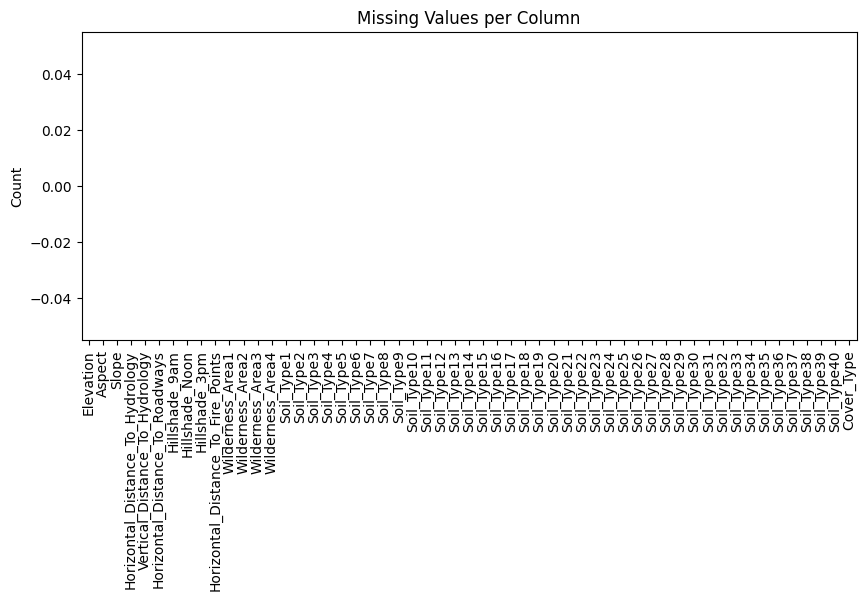

In [102]:
missing = df.isnull().sum()

plt.figure(figsize=(10,4))
missing.plot(kind='bar')
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.show()

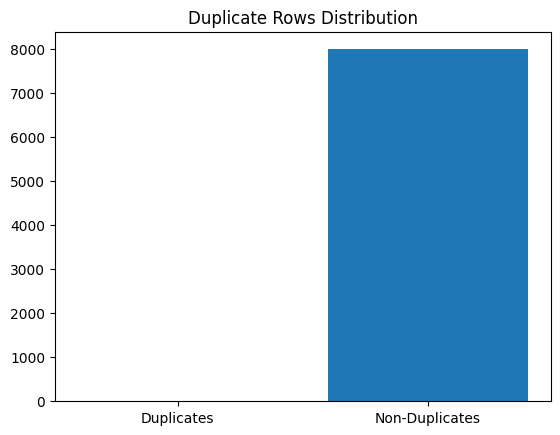

In [103]:
duplicates = df.duplicated().sum()

plt.bar(["Duplicates", "Non-Duplicates"], [duplicates, len(df)-duplicates])
plt.title("Duplicate Rows Distribution")
plt.show()

## Domain Cleaning 

Domain-based cleaning was performed by validating each feature according to its real-world meaning. Terrain variables such as elevation, aspect, and slope were restricted to physically valid ranges, distance variables were checked to ensure non-negative values, and hillshade features were constrained between 0 and 255. Binary soil and wilderness indicators were validated to contain only 0 and 1, while the target variable was restricted to the seven defined forest cover classes. This step removed unrealistic observations and ensured that the dataset remained consistent and meaningful for further analysis.

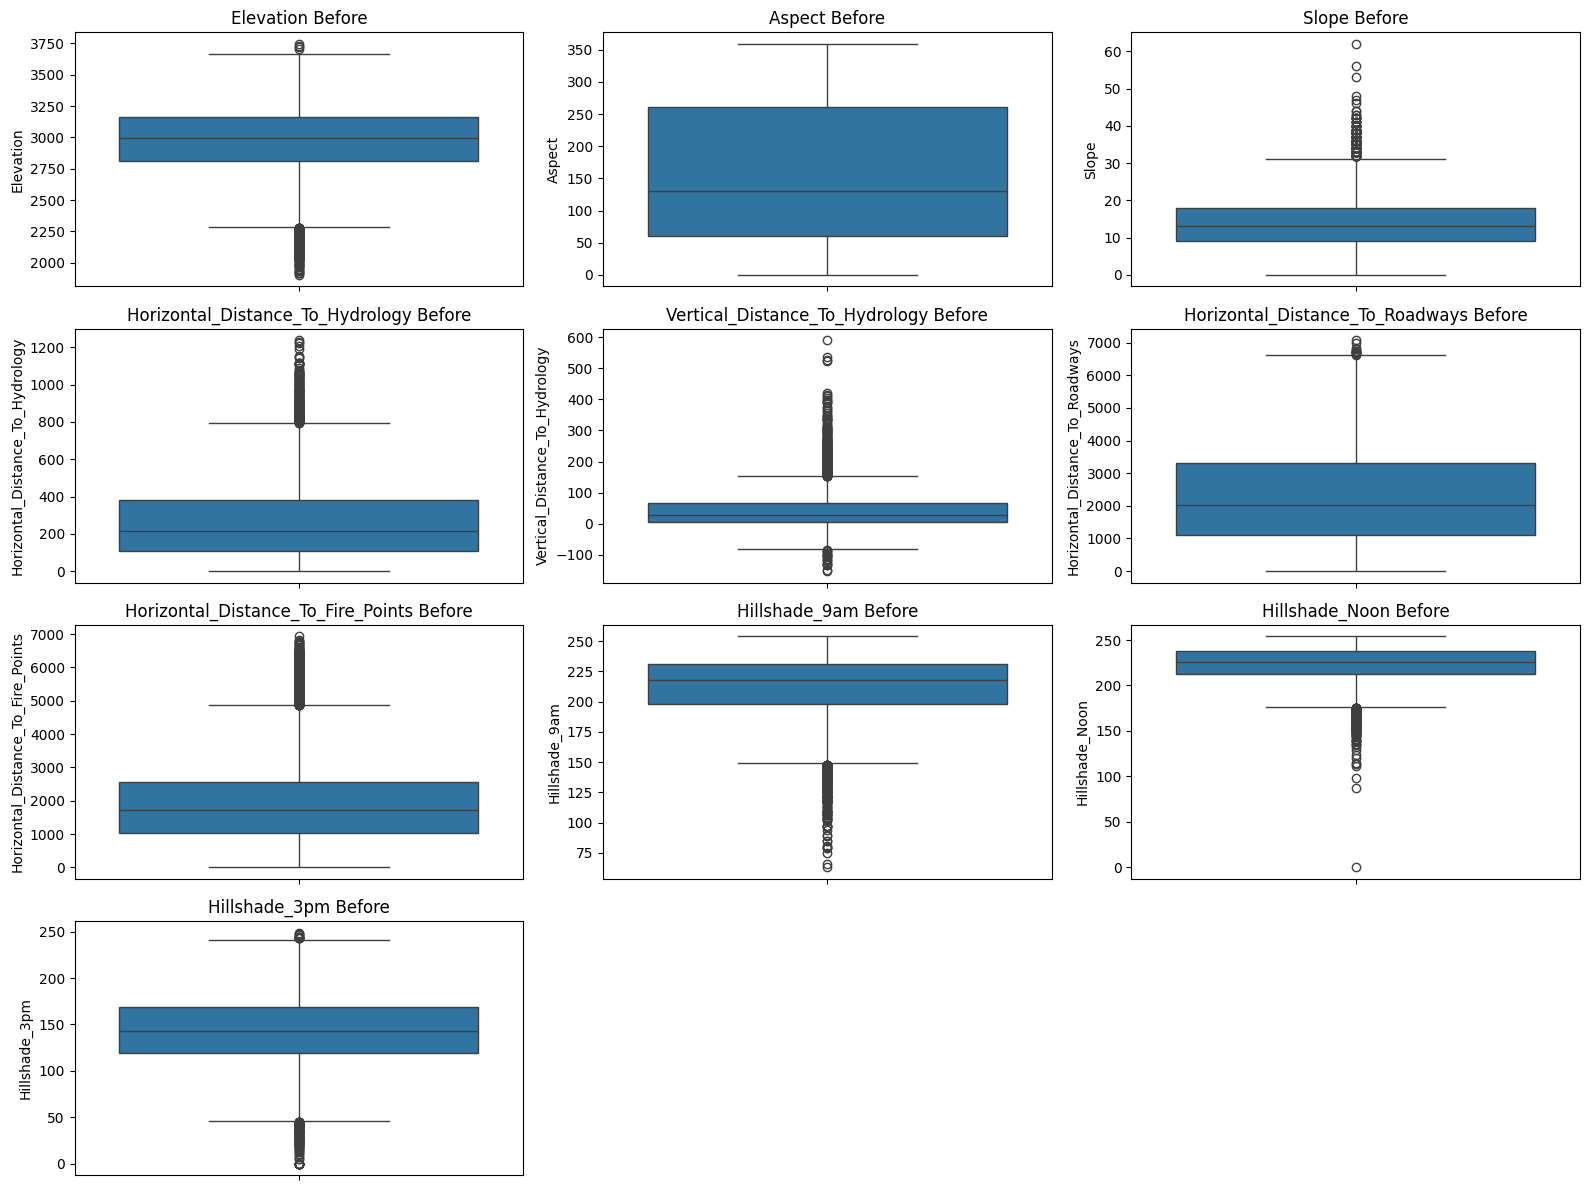

In [104]:
numeric_cols = [
    'Elevation','Aspect','Slope',
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Horizontal_Distance_To_Fire_Points',
    'Hillshade_9am','Hillshade_Noon','Hillshade_3pm'
]

plt.figure(figsize=(16,12))
for i, col in enumerate(numeric_cols,1):
    plt.subplot(4,3,i)
    sns.boxplot(y=df[col])
    plt.title(f"{col} Before")
plt.tight_layout()
plt.show()

In [105]:
# Elevation
invalid_elevation = df[(df['Elevation'] <= 0) | (df['Elevation'] > 5000)]
print("Invalid Elevation rows:", len(invalid_elevation))

# Aspect
invalid_aspect = df[(df['Aspect'] < 0) | (df['Aspect'] > 360)]
print("Invalid Aspect rows:", len(invalid_aspect))

# Slope
invalid_slope = df[(df['Slope'] < 0) | (df['Slope'] > 90)]
print("Invalid Slope rows:", len(invalid_slope))

# Distance features
invalid_hydrology = df[df['Horizontal_Distance_To_Hydrology'] < 0]
print("Invalid Horizontal_Distance_To_Hydrology rows:", len(invalid_hydrology))

invalid_roadways = df[df['Horizontal_Distance_To_Roadways'] < 0]
print("Invalid Horizontal_Distance_To_Roadways rows:", len(invalid_roadways))

invalid_fire = df[df['Horizontal_Distance_To_Fire_Points'] < 0]
print("Invalid Horizontal_Distance_To_Fire_Points rows:", len(invalid_fire))

# Hillshade features
invalid_hill_9 = df[(df['Hillshade_9am'] < 0) | (df['Hillshade_9am'] > 255)]
print("Invalid Hillshade_9am rows:", len(invalid_hill_9))

invalid_hill_noon = df[(df['Hillshade_Noon'] < 0) | (df['Hillshade_Noon'] > 255)]
print("Invalid Hillshade_Noon rows:", len(invalid_hill_noon))

invalid_hill_3 = df[(df['Hillshade_3pm'] < 0) | (df['Hillshade_3pm'] > 255)]
print("Invalid Hillshade_3pm rows:", len(invalid_hill_3))

Invalid Elevation rows: 0
Invalid Aspect rows: 0
Invalid Slope rows: 0
Invalid Horizontal_Distance_To_Hydrology rows: 0
Invalid Horizontal_Distance_To_Roadways rows: 0
Invalid Horizontal_Distance_To_Fire_Points rows: 0
Invalid Hillshade_9am rows: 0
Invalid Hillshade_Noon rows: 0
Invalid Hillshade_3pm rows: 0


In [106]:
wilderness_cols = [c for c in df.columns if "Wilderness_Area" in c]
soil_cols = [c for c in df.columns if "Soil_Type" in c]

for col in wilderness_cols:
    invalid = df[~df[col].isin([0, 1])]
    print(f"Invalid values in {col}: {len(invalid)}")

for col in soil_cols:
    invalid = df[~df[col].isin([0, 1])]
    print(f"Invalid values in {col}: {len(invalid)}")

Invalid values in Wilderness_Area1: 0
Invalid values in Wilderness_Area2: 0
Invalid values in Wilderness_Area3: 0
Invalid values in Wilderness_Area4: 0
Invalid values in Soil_Type1: 0
Invalid values in Soil_Type2: 0
Invalid values in Soil_Type3: 0
Invalid values in Soil_Type4: 0
Invalid values in Soil_Type5: 0
Invalid values in Soil_Type6: 0
Invalid values in Soil_Type7: 0
Invalid values in Soil_Type8: 0
Invalid values in Soil_Type9: 0
Invalid values in Soil_Type10: 0
Invalid values in Soil_Type11: 0
Invalid values in Soil_Type12: 0
Invalid values in Soil_Type13: 0
Invalid values in Soil_Type14: 0
Invalid values in Soil_Type15: 0
Invalid values in Soil_Type16: 0
Invalid values in Soil_Type17: 0
Invalid values in Soil_Type18: 0
Invalid values in Soil_Type19: 0
Invalid values in Soil_Type20: 0
Invalid values in Soil_Type21: 0
Invalid values in Soil_Type22: 0
Invalid values in Soil_Type23: 0
Invalid values in Soil_Type24: 0
Invalid values in Soil_Type25: 0
Invalid values in Soil_Type26: 0

In [107]:
invalid_target = df[~df['Cover_Type'].isin([1, 2, 3, 4, 5, 6, 7])]
print("Invalid Cover_Type rows:", len(invalid_target))

Invalid Cover_Type rows: 0


In [108]:
# Terrain rules
df = df[(df['Elevation'] > 0) & (df['Elevation'] <= 5000)]
df = df[(df['Aspect'] >= 0) & (df['Aspect'] <= 360)]
df = df[(df['Slope'] >= 0) & (df['Slope'] <= 90)]

# Distance rules
df = df[df['Horizontal_Distance_To_Hydrology'] >= 0]
df = df[df['Horizontal_Distance_To_Roadways'] >= 0]
df = df[df['Horizontal_Distance_To_Fire_Points'] >= 0]

# Hillshade rules
for col in ['Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm']:
    df = df[(df[col] >= 0) & (df[col] <= 255)]

# Binary rules
for col in wilderness_cols:
    df = df[df[col].isin([0, 1])]

for col in soil_cols:
    df = df[df[col].isin([0, 1])]

# Target rule
df = df[df['Cover_Type'].isin([1, 2, 3, 4, 5, 6, 7])]

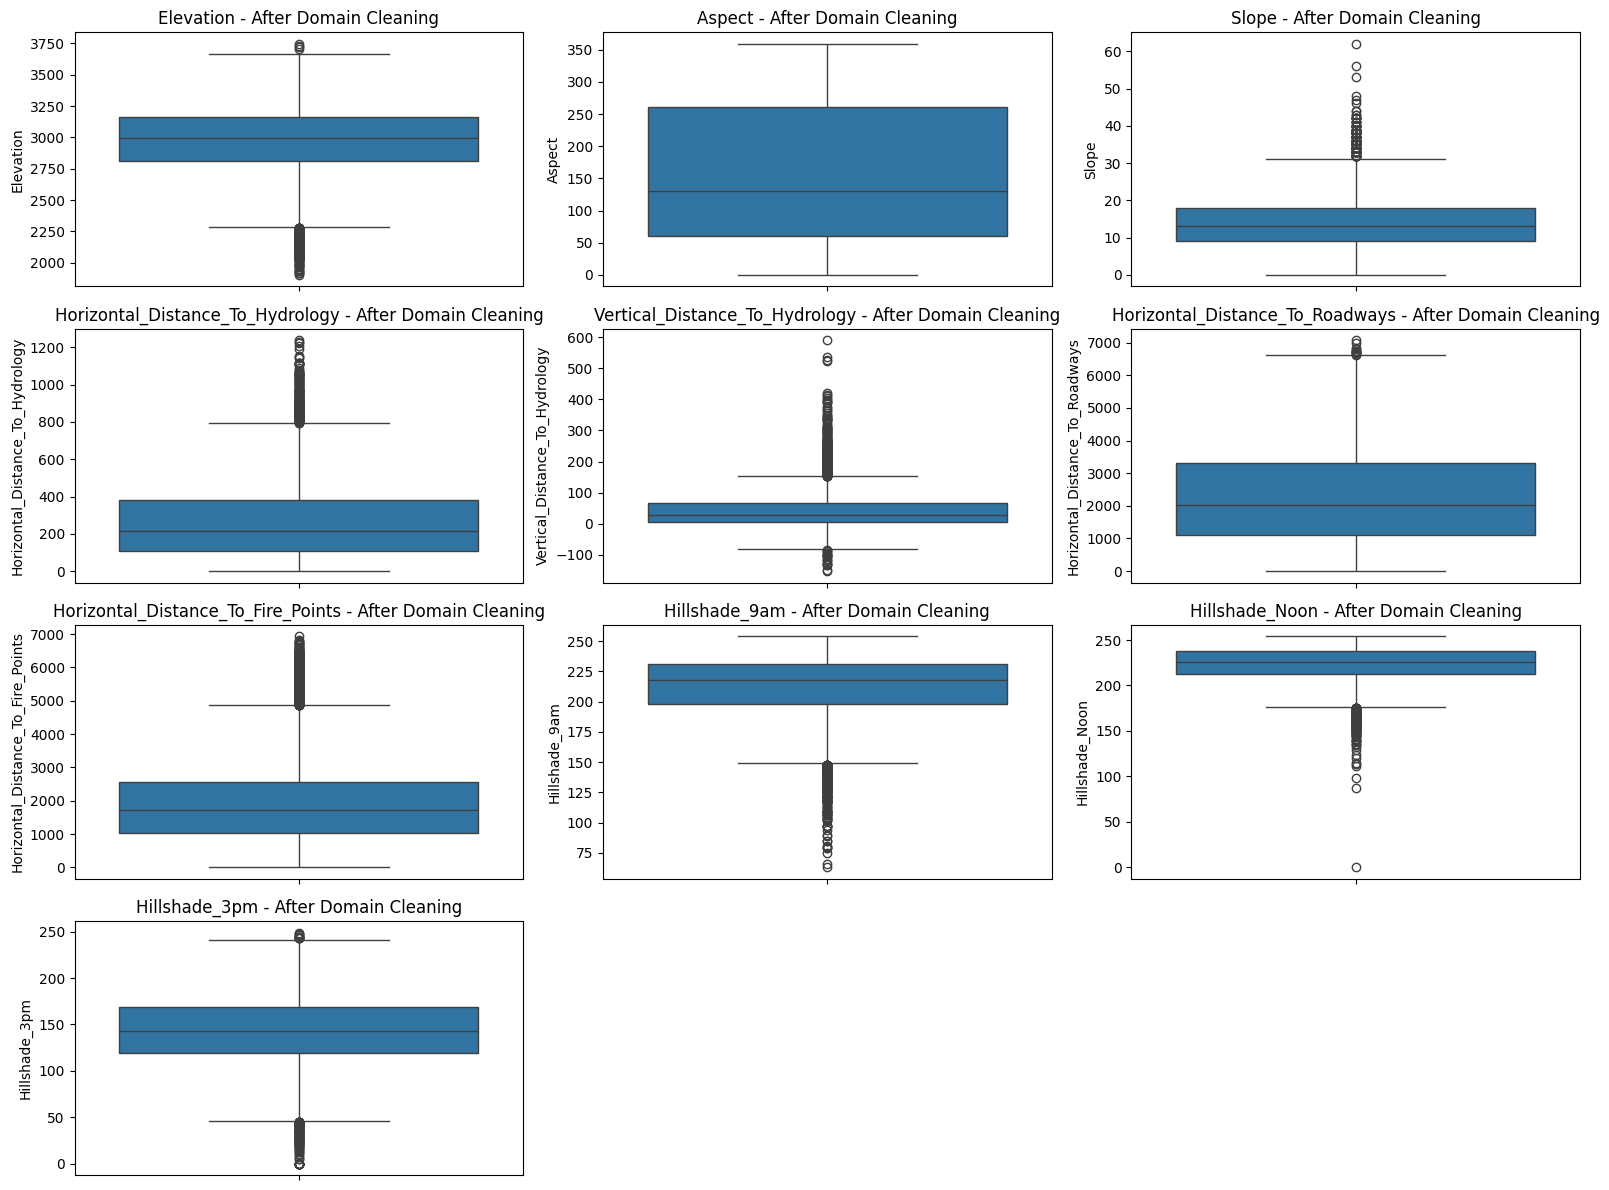

In [109]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"{col} - After Domain Cleaning")

plt.tight_layout()
plt.show()

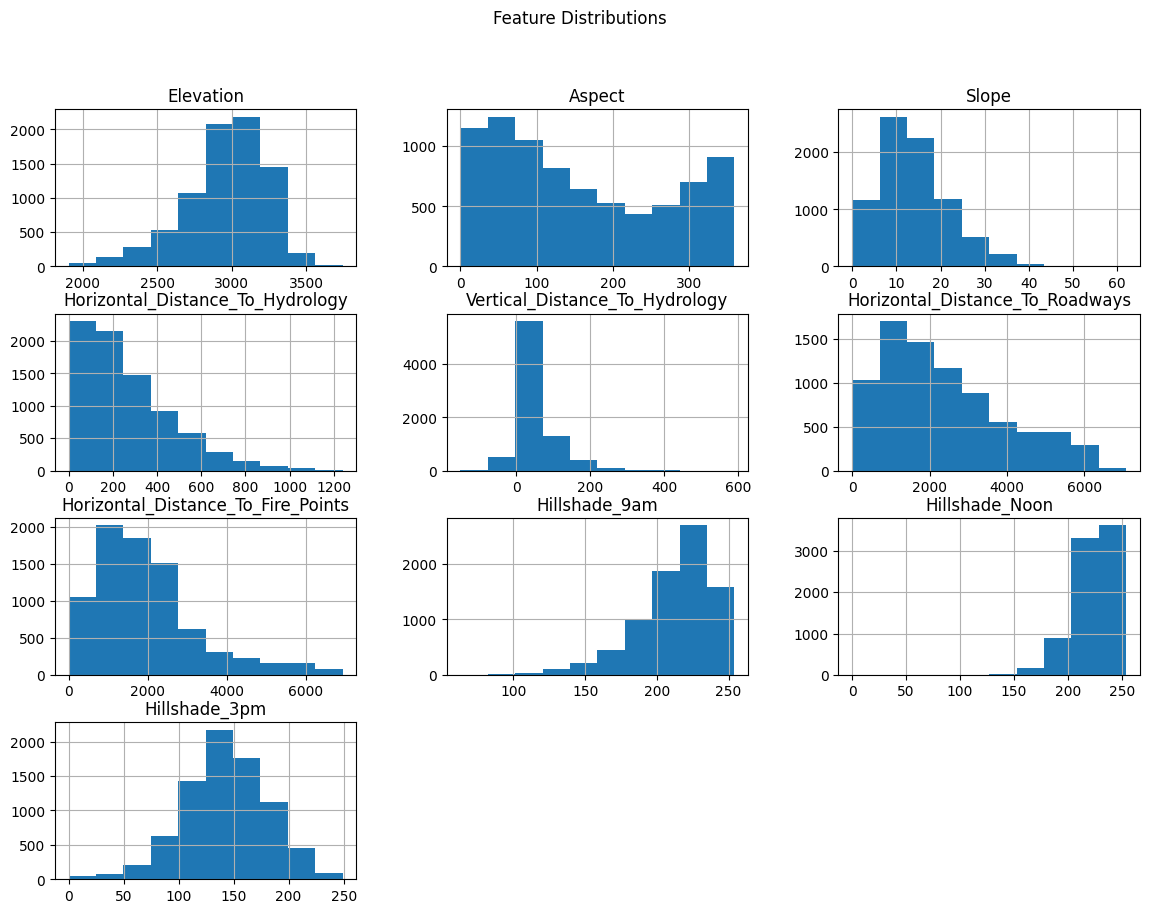

In [110]:
df[numeric_cols].hist(figsize=(14,10))
plt.suptitle("Feature Distributions")
plt.show()

The before-and-after boxplots were used to confirm whether invalid values existed in the numerical features. Features that showed no noticeable change were already within valid domain ranges, while any removed values reflected unrealistic or impossible measurements.

## Skewness Handling

Skewness analysis identified highly skewed distance features, which were handled using 99th percentile capping to improve distribution balance.

In [111]:
from scipy.stats import skew
skew_values = []

for col in numeric_cols:
    skew_values.append(skew(df[col]))

import pandas as pd

skew_df = pd.DataFrame({
    "Feature": numeric_cols,
    "Skewness": skew_values
})

skew_df

,Feature,Skewness
0,Elevation,-0.837581
1,Aspect,0.378423
2,Slope,0.858739
3,Horizontal_Distance_To_Hydrology,1.124141
4,Vertical_Distance_To_Hydrology,1.991400
5,Horizontal_Distance_To_Roadways,0.727253
6,Horizontal_Distance_To_Fire_Points,1.261828
7,Hillshade_9am,-1.217317
8,Hillshade_Noon,-1.198249
9,Hillshade_3pm,-0.274276


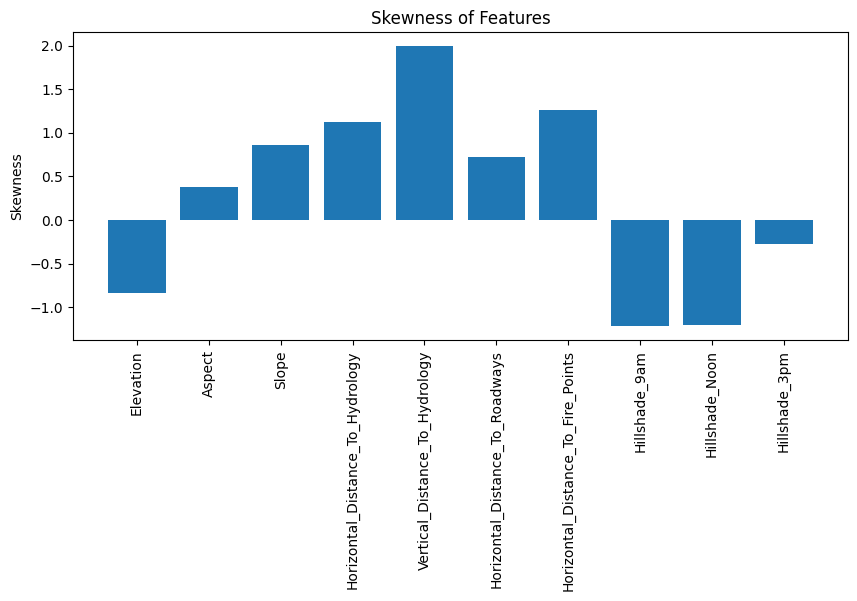

In [112]:
plt.figure(figsize=(10,4))
plt.bar(skew_df["Feature"], skew_df["Skewness"])
plt.xticks(rotation=90)
plt.title("Skewness of Features")
plt.ylabel("Skewness")
plt.show()

## Handeling Outliers

Outlier handling aims to reduce the influence of extreme values that distort feature distributions while preserving valid observations. Unlike domain cleaning, which removes invalid data, outlier handling focuses on managing extreme but realistic values.

based on distribution and skewness analysis, the most affected features are:

In [113]:
distance_cols = [
    'Horizontal_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Horizontal_Distance_To_Fire_Points'
]

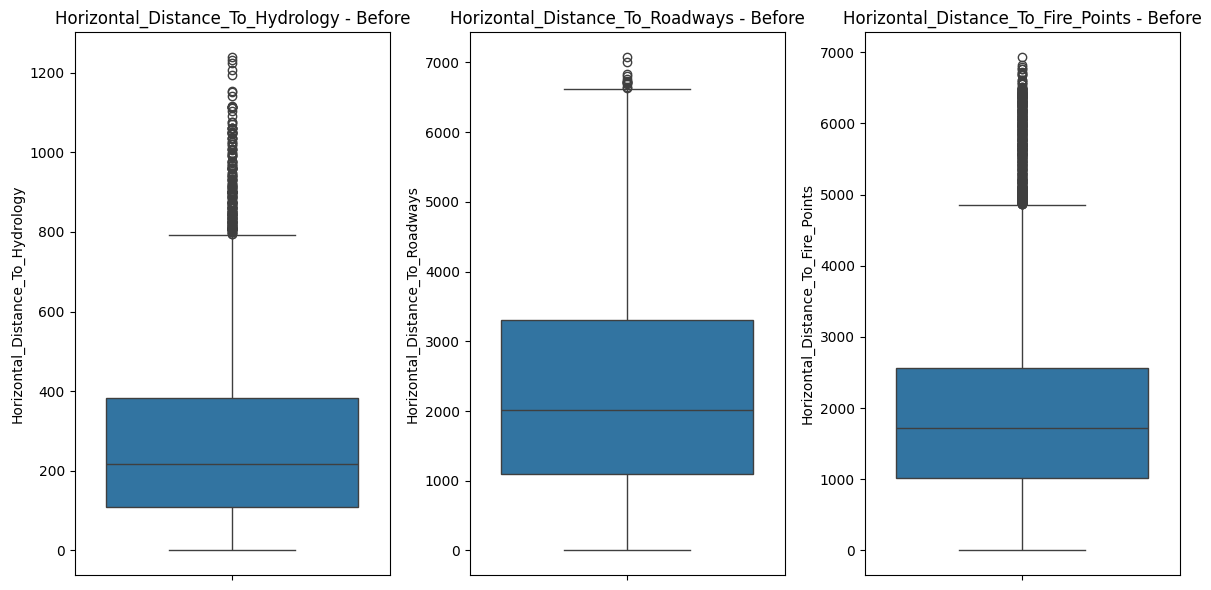

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

for i, col in enumerate(distance_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"{col} - Before")

plt.tight_layout()
plt.show()

In [115]:
def outlier_stats(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    
    return lower, upper, count

for col in distance_cols:
    lower, upper, count = outlier_stats(df, col)
    print(f"{col}: {count} outliers (IQR method)")

Horizontal_Distance_To_Hydrology: 196 outliers (IQR method)
Horizontal_Distance_To_Roadways: 13 outliers (IQR method)
Horizontal_Distance_To_Fire_Points: 404 outliers (IQR method)


In [116]:
df_out = df.copy()

treatment_summary = []

for col in distance_cols:
    
    upper_cap = df_out[col].quantile(0.99)
    
    before_vals = df_out[col].copy()
    df_out[col] = df_out[col].clip(upper=upper_cap)
    
    treated_count = (before_vals != df_out[col]).sum()
    
    treatment_summary.append({
        "Feature": col,
        "Method": "Capping (99th percentile)",
        "Values Adjusted": treated_count,
        "Percentage": round((treated_count / len(df_out)) * 100, 2)
    })

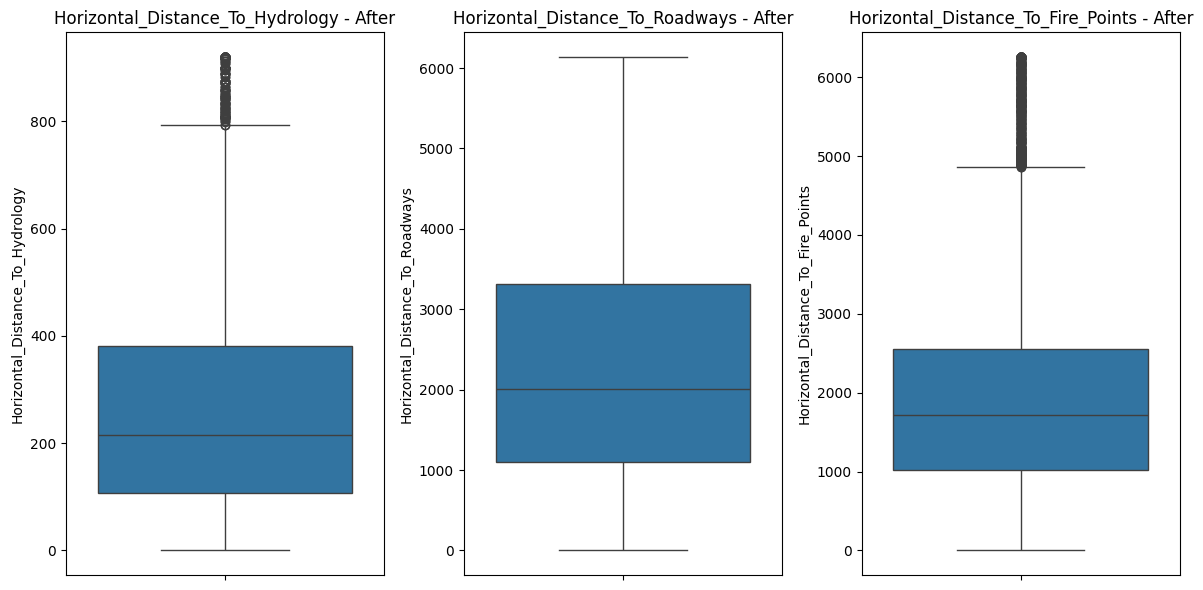

In [117]:
plt.figure(figsize=(12, 6))

for i, col in enumerate(distance_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_out[col])
    plt.title(f"{col} - After")

plt.tight_layout()
plt.show()

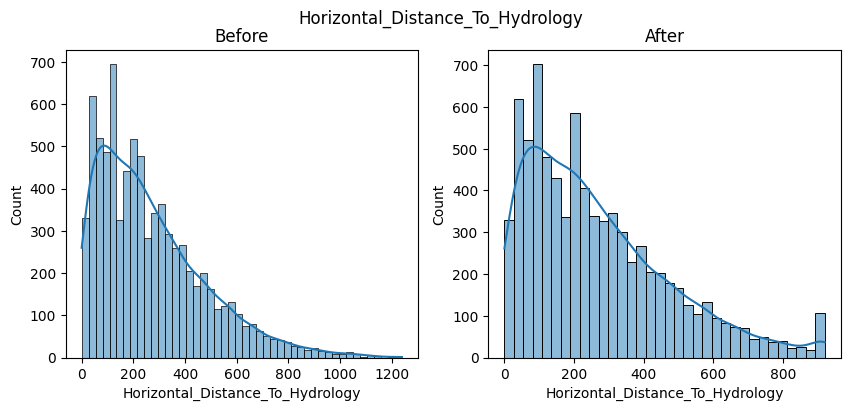

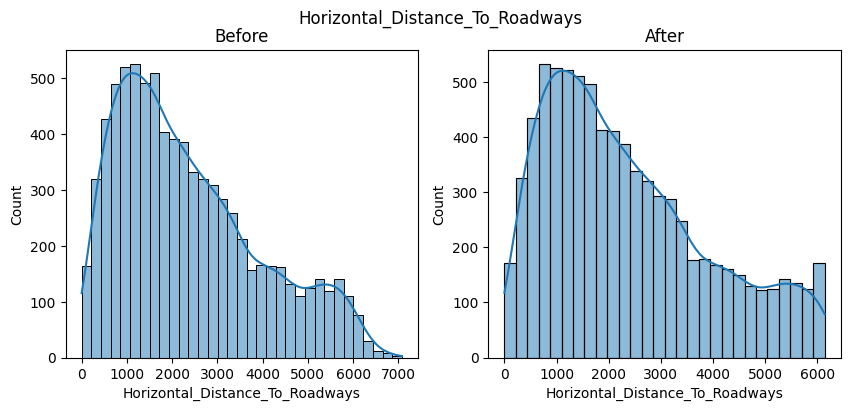

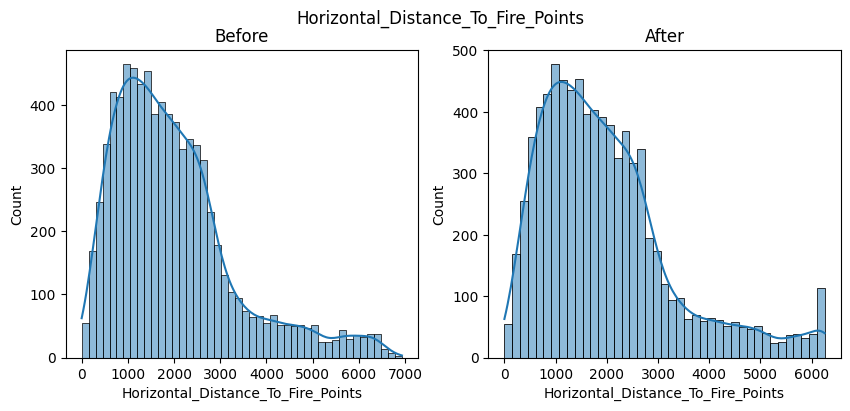

In [118]:
for col in distance_cols:
    
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title("Before")
    
    plt.subplot(1,2,2)
    sns.histplot(df_out[col], kde=True)
    plt.title("After")
    
    plt.suptitle(col)
    plt.show()

In [119]:
df = df_out.copy()

Outliers in distance features were handled using 99th percentile capping to reduce extreme values while preserving all observations. Importantly, the main structure of the data remained unchanged, indicating that the majority of observations were preserved while only extreme values were adjusted. This confirms that capping successfully reduced the impact of outliers without distorting the overall distribution

## Feature Engineering

In [120]:
def clean_and_engineer(df):
    df = df.copy()
    # Domain cleaning
    df = df[(df['Elevation'] > 0) & (df['Elevation'] <= 5000)]
    df = df[(df['Aspect'] >= 0) & (df['Aspect'] <= 360)]
    # ... باقي الـ rules

    # Feature engineering
    df['Hillshade_mean'] = df[['Hillshade_9am','Hillshade_Noon','Hillshade_3pm']].mean(axis=1)
    df['Total_Distance'] = df[['Horizontal_Distance_To_Hydrology',
                                'Horizontal_Distance_To_Roadways',
                                'Horizontal_Distance_To_Fire_Points']].sum(axis=1)
    df['Vertical_Distance_To_Hydrology_Abs'] = df['Vertical_Distance_To_Hydrology'].abs()
    return df

df       = clean_and_engineer(df)
data_test = clean_and_engineer(data_test)

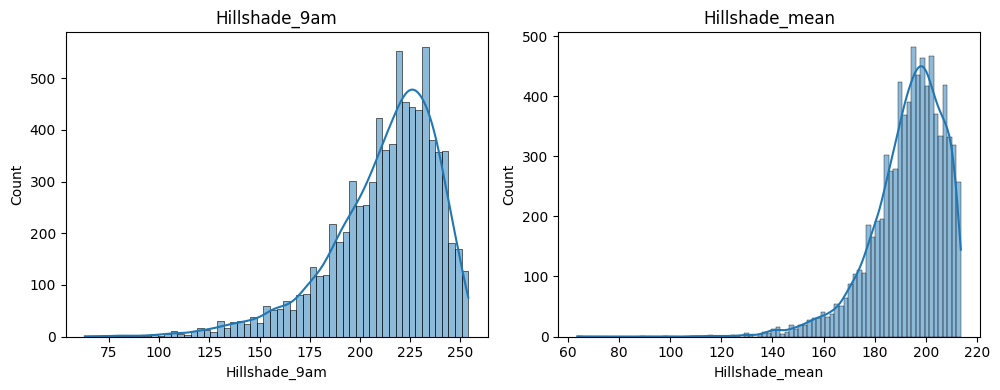

In [121]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Hillshade_9am'], kde=True)
plt.title("Hillshade_9am")

plt.subplot(1,2,2)
sns.histplot(df['Hillshade_mean'], kde=True)
plt.title("Hillshade_mean")

plt.tight_layout()
plt.show()

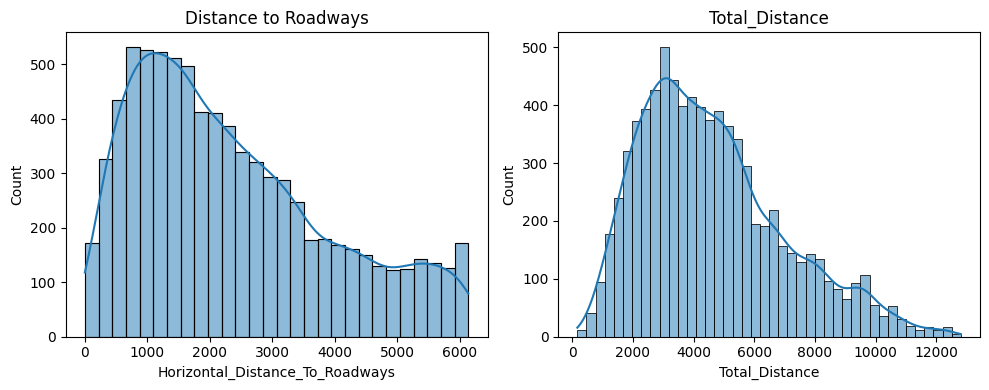

In [122]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Horizontal_Distance_To_Roadways'], kde=True)
plt.title("Distance to Roadways")

plt.subplot(1,2,2)
sns.histplot(df['Total_Distance'], kde=True)
plt.title("Total_Distance")

plt.tight_layout()
plt.show()

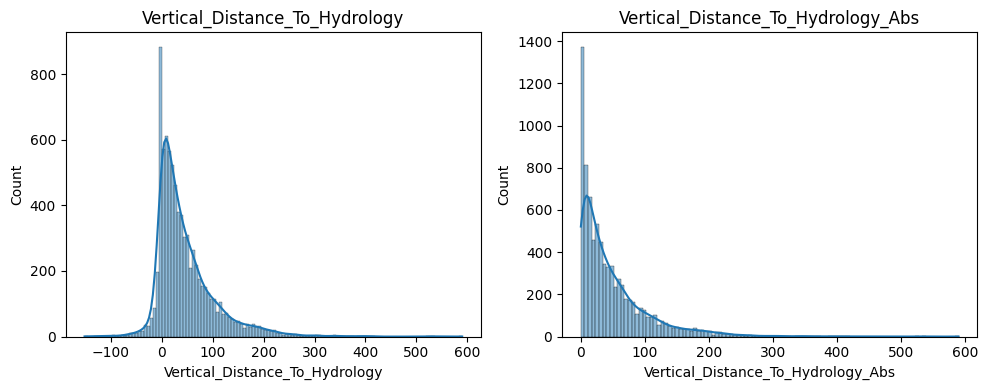

In [123]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Vertical_Distance_To_Hydrology'], kde=True)
plt.title("Vertical_Distance_To_Hydrology")

plt.subplot(1,2,2)
sns.histplot(df['Vertical_Distance_To_Hydrology_Abs'], kde=True)
plt.title("Vertical_Distance_To_Hydrology_Abs")

plt.tight_layout()
plt.show()

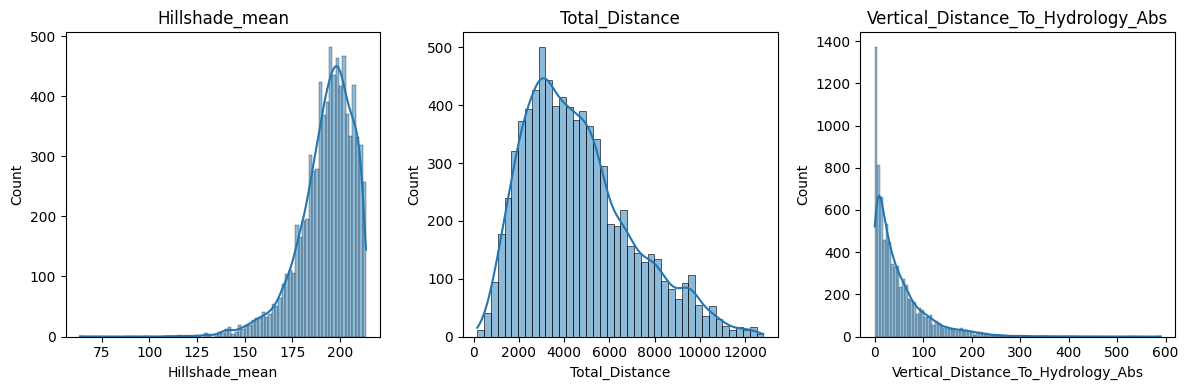

In [124]:
engineered_cols = [
    'Hillshade_mean',
    'Total_Distance',
    'Vertical_Distance_To_Hydrology_Abs'
]

plt.figure(figsize=(12,4))

for i, col in enumerate(engineered_cols, 1):
    plt.subplot(1,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

Feature engineering was applied to create more informative variables from the original dataset. First, an average hillshade feature was created by combining the hillshade measurements at 9am, noon, and 3pm. This provides a more general representation of sunlight intensity across the day. Second, a total distance feature was created by summing the horizontal distances to hydrology, roadways, and fire points, giving a broader measure of location remoteness. Third, the vertical distance to hydrology was transformed into an absolute-value feature to focus on the magnitude of the distance rather than its direction. These engineered variables improve interpretability and strengthen the dataset for later analysis.

## Feature Scaling

In [125]:
df_scale = df.copy()
data_test_scale = data_test.copy()

In [126]:
scale_cols = [
    'Elevation',
    'Aspect',
    'Slope',
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Horizontal_Distance_To_Fire_Points',
    'Hillshade_9am',
    'Hillshade_Noon',
    'Hillshade_3pm',
    'Hillshade_mean',
    'Total_Distance',
    'Vertical_Distance_To_Hydrology_Abs'
]

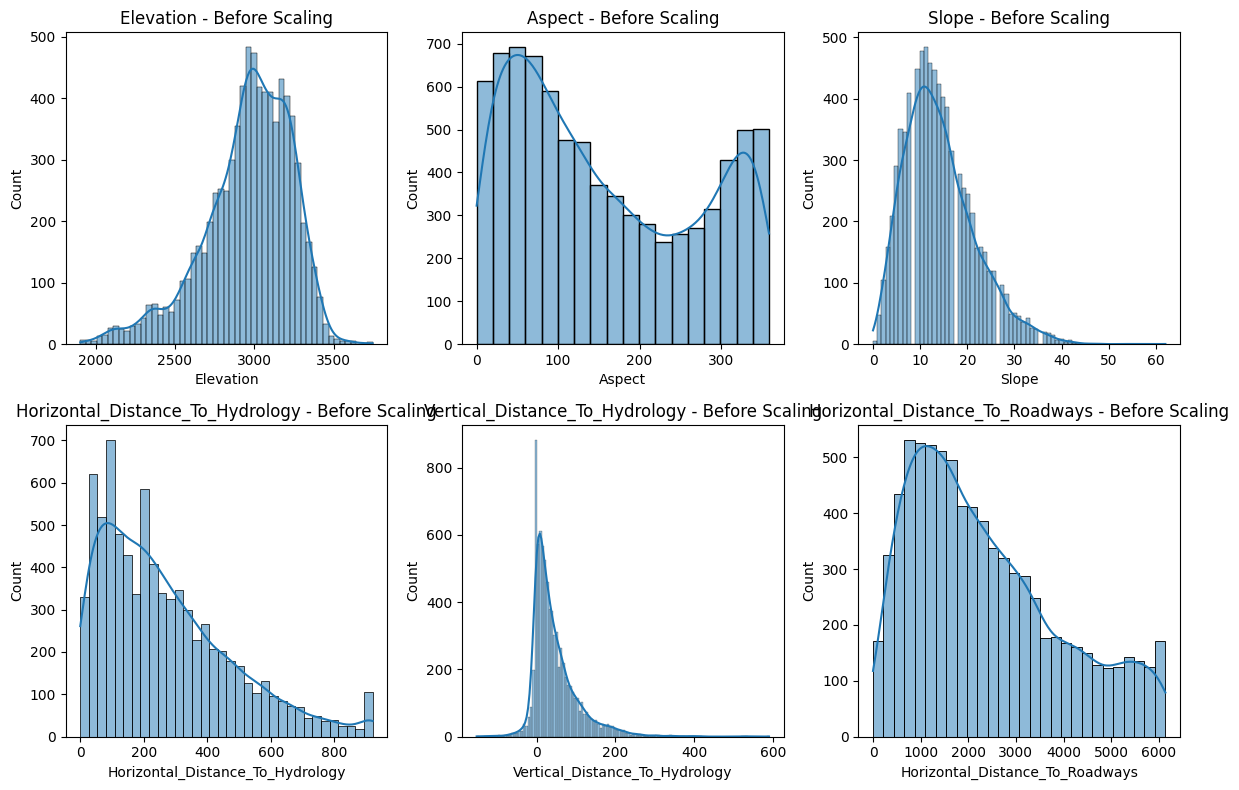

In [127]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(scale_cols[:6], 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_scale[col], kde=True)
    plt.title(f"{col} - Before Scaling")

plt.tight_layout()
plt.show()

In [128]:
scaler = StandardScaler()

df_scaled = df_scale.copy()
data_test_scaled = data_test_scale.copy()

df_scaled[scale_cols] = scaler.fit_transform(df_scale[scale_cols])
data_test_scaled[scale_cols] = scaler.transform(data_test_scale[scale_cols])


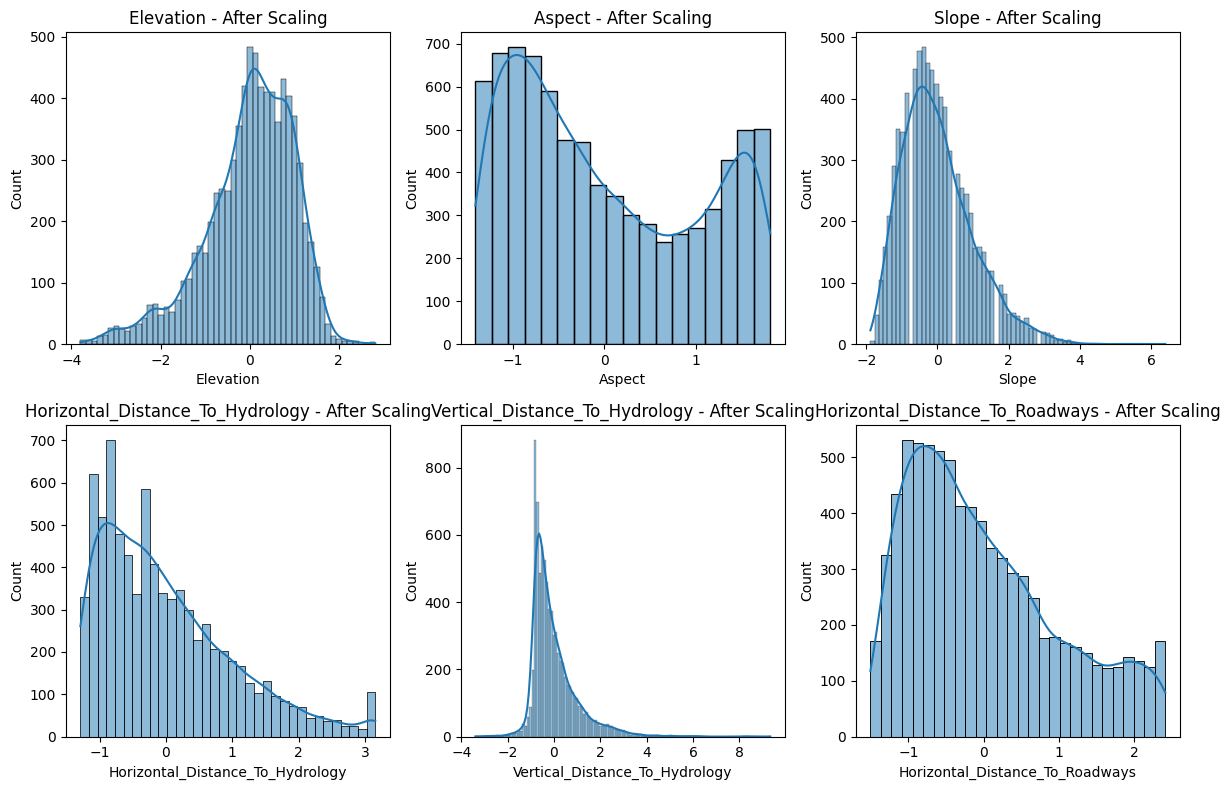

In [129]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(scale_cols[:6], 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_scaled[col], kde=True)
    plt.title(f"{col} - After Scaling")

plt.tight_layout()
plt.show()

In [130]:
df = df_scaled.copy()
data_test = data_test_scaled.copy()

Feature scaling was applied to continuous numerical variables in order to place them on a comparable scale. This step is useful when features have very different ranges, such as elevation, hillshade, and distance variables. Standardization was used, transforming each selected feature to have a mean close to zero and a standard deviation close to one. Binary encoded features and the target variable were excluded from scaling because their values already carry categorical meaning. Although scaling is not required for tree-based models, it was included to improve consistency and prepare the dataset for other machine learning algorithms that are sensitive to feature magnitude.

## Correlation Check

In [131]:
numeric_df = df.select_dtypes(include='number')

In [132]:
corr_matrix = numeric_df.corr()

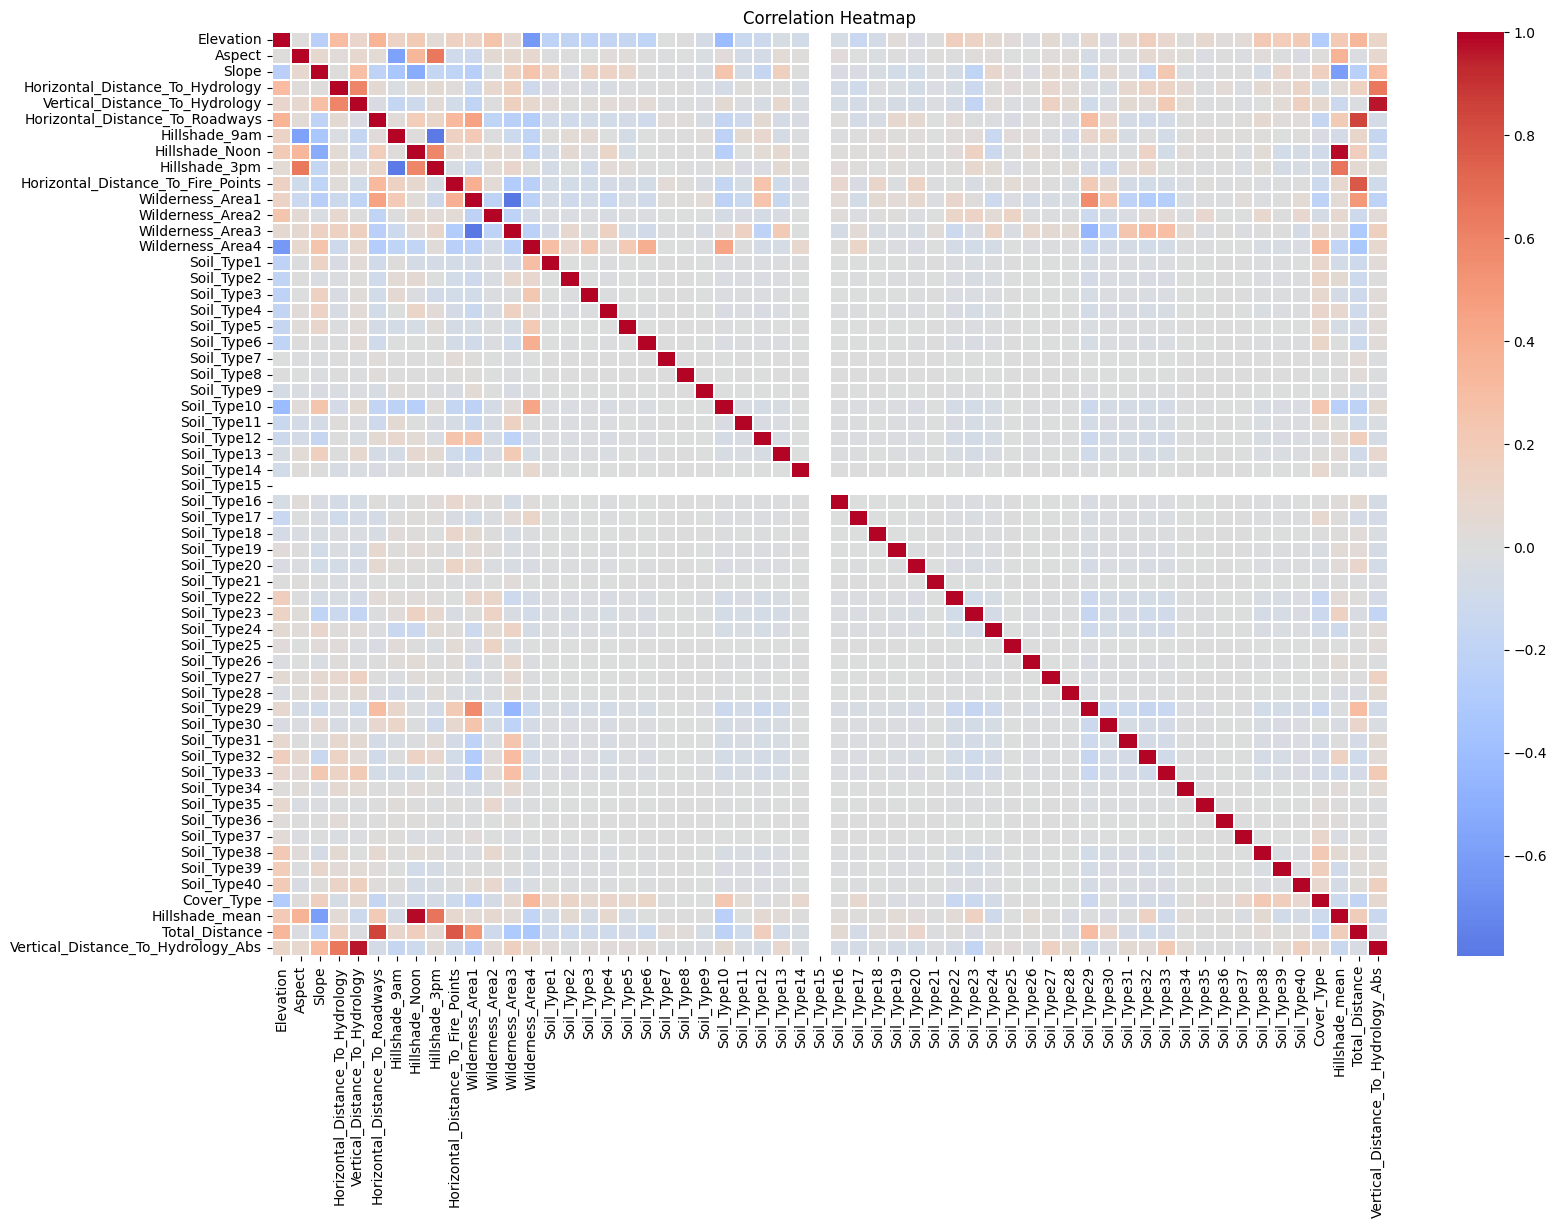

In [133]:
plt.figure(figsize=(18,12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.2
)

plt.title("Correlation Heatmap")
plt.show()

<Axes: >

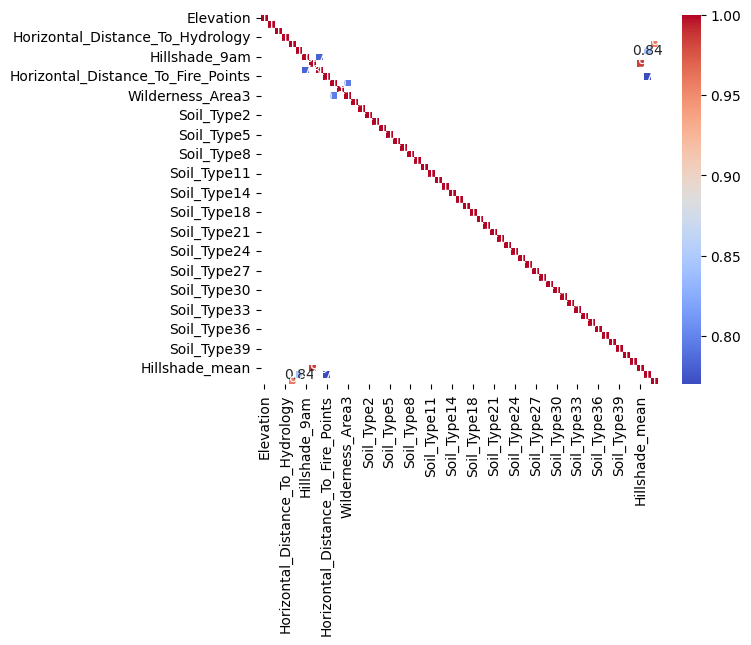

In [134]:
high_corr = (
    corr_matrix
    .abs()
    .where(lambda x: x > 0.7)
    .dropna(how='all')
    .dropna(axis=1, how='all')
)

sns.heatmap(high_corr, annot=True, cmap='coolwarm')

A correlation heatmap was generated to examine relationships between features. The majority of feature pairs show weak correlations, indicating low multicollinearity within the dataset.

Moderate correlations were observed among hillshade features and some distance-based variables, which is expected due to their physical relationships.

Since no strong correlations (above 0.9) were detected, no features were removed. Additionally, tree-based models such as Random Forest are robust to multicollinearity, supporting the decision to retain all features.

The target variable does not show strong linear correlation with any individual feature, suggesting that forest cover type depends on a combination of environmental and soil factors rather than a single dominant variable.

### Corelation with Target

In [135]:
target_corr = corr_matrix['Cover_Type'].sort_values(ascending=False)

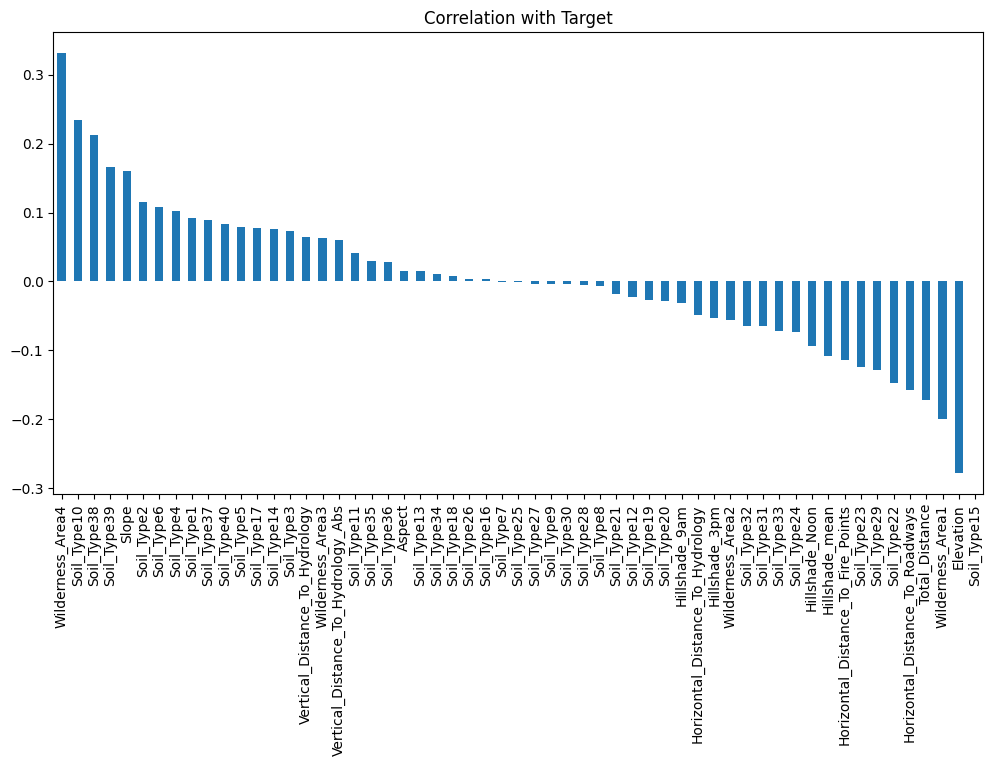

In [136]:
target_corr.drop('Cover_Type').plot(kind='bar', figsize=(12,6))
plt.title("Correlation with Target")
plt.show()

Correlation analysis was performed to examine the relationships between numerical features. A heatmap was used to visualize pairwise correlations and identify strongly related variables.

The results showed that some features, such as hillshade variables, are moderately correlated with each other, while most other features exhibit weak to moderate relationships. No extremely high correlations were observed that would require aggressive feature removal.

Additionally, correlation with the target variable indicated that no single feature strongly predicts the output, supporting the earlier observation that the problem requires a combination of features rather than relying on individual variables.

## Class Imbalance

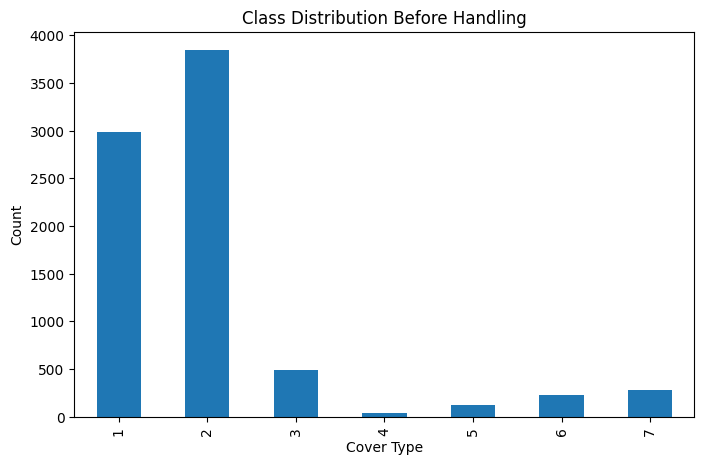

In [137]:
class_counts_before = df['Cover_Type'].value_counts().sort_index()

plt.figure(figsize=(8,5))
class_counts_before.plot(kind='bar')
plt.title("Class Distribution Before Handling")
plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.show()

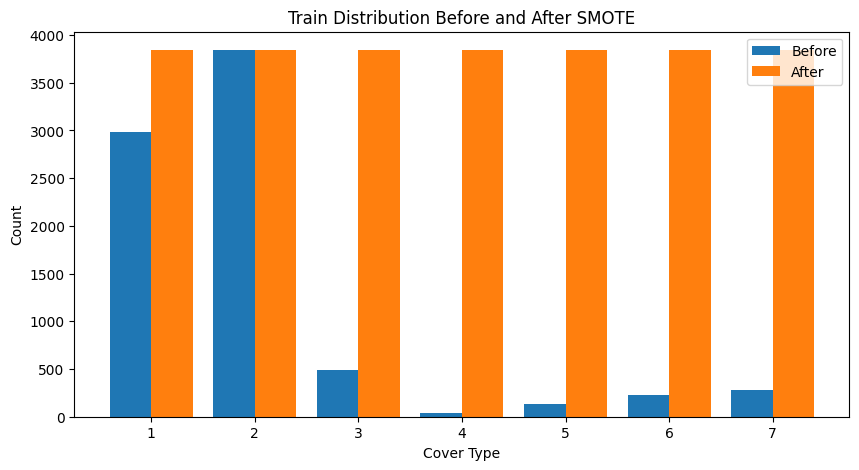

In [138]:
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt


X_train = df.drop('Cover_Type', axis=1)
y_train = df['Cover_Type']


smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


before = y_train.value_counts().sort_index()
after = pd.Series(y_train_res).value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(before.index - 0.2, before.values, width=0.4, label='Before')
plt.bar(after.index + 0.2, after.values, width=0.4, label='After')

plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.title("Train Distribution Before and After SMOTE")
plt.legend()
plt.show()

In [139]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
df = pd.concat([X_train_res, y_train_res], axis=1)

The dataset showed strong class imbalance across forest cover types. Full SMOTE on the entire dataset was computationally expensive due to the large dataset size and severe imbalance. Therefore, imbalance handling was demonstrated either on a representative sample or using a simpler oversampling technique for visualization purposes. This still clearly shows how minority classes can be balanced before modeling.

# PCA

In [140]:
X_train = X_train_res
y_train = pd.Series(y_train_res, name='Cover_Type')
X_test  = data_test.drop('Cover_Type', axis=1)
y_test  = data_test['Cover_Type']

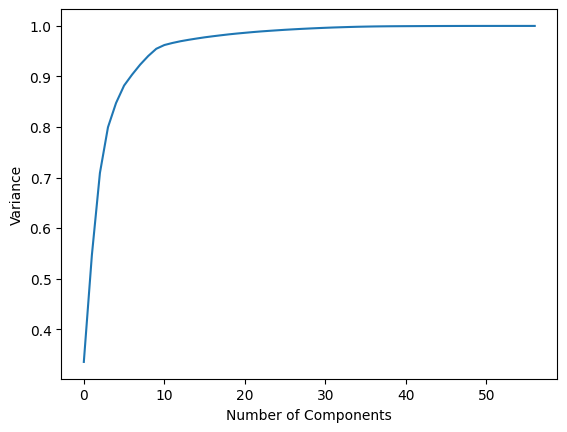

In [141]:
pca = PCA()
pca.fit(X_train)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Variance')
plt.show()

In [142]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

evr = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)

In [143]:
thresholds = [0.80, 0.90, 0.95, 0.99]

print("Explained Variance Thresholds:")
print(f"{'Threshold':>10}  {'Components':>12}  {'Reduction':>10}")
print("-" * 36)

for t in thresholds:
    n = np.argmax(cumulative >= t) + 1
    pct_red = (1 - n / X_train.shape[1]) * 100
    print(f"{t*100:>9.0f}%  {n:>12}  {pct_red:>9.1f}%")

print()

Explained Variance Thresholds:
 Threshold    Components   Reduction
------------------------------------
       80%             5       91.2%
       90%             7       87.7%
       95%            10       82.5%
       99%            24       57.9%



In [144]:
N_COMPONENTS = np.argmax(cumulative >= 0.95) + 1

print(f"✓ Best Choice: {N_COMPONENTS} components → 95% variance")
print(f"  Reduction: {X_train.shape[1]} → {N_COMPONENTS}")
print(f"  ({(1 - N_COMPONENTS / X_train.shape[1]) * 100:.0f}% reduction)")
print()

✓ Best Choice: 10 components → 95% variance
  Reduction: 57 → 10
  (82% reduction)



In [145]:
pca = PCA(n_components=N_COMPONENTS, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Final Shape after PCA: {X_train_pca.shape}")
print()

Final Shape after PCA: (26894, 10)



# SVM

In [146]:
param_grid = {
    'C':     [1, 10, 100 , 1000] ,
    'gamma': ['scale', 0.01]
}

svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42,
    cache_size=1000
)

grid = GridSearchCV(
    svm,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1)

grid.fit(X_train_pca, y_train)

print("Best Params:", grid.best_params_)

y_pred = grid.best_estimator_.predict(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Params: {'C': 1000, 'gamma': 'scale'}
Accuracy: 0.7405
              precision    recall  f1-score   support

           1       0.71      0.76      0.73       696
           2       0.80      0.76      0.78       999
           3       0.72      0.70      0.71       129
           4       0.45      0.71      0.56         7
           5       0.38      0.55      0.45        31
           6       0.57      0.45      0.50        71
           7       0.70      0.66      0.68        67

    accuracy                           0.74      2000
   macro avg       0.62      0.66      0.63      2000
weighted avg       0.74      0.74      0.74      2000



In [147]:
print("=== TUNED SVM ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Best Params: {grid.best_params_}")
print(f"Best CV F1 : {grid.best_score_:.4f}")
print()
print(classification_report(y_test, y_pred))

=== TUNED SVM ===
Accuracy  : 0.7405
F1 Score  : 0.7413
Best Params: {'C': 1000, 'gamma': 'scale'}
Best CV F1 : 0.9297

              precision    recall  f1-score   support

           1       0.71      0.76      0.73       696
           2       0.80      0.76      0.78       999
           3       0.72      0.70      0.71       129
           4       0.45      0.71      0.56         7
           5       0.38      0.55      0.45        31
           6       0.57      0.45      0.50        71
           7       0.70      0.66      0.68        67

    accuracy                           0.74      2000
   macro avg       0.62      0.66      0.63      2000
weighted avg       0.74      0.74      0.74      2000



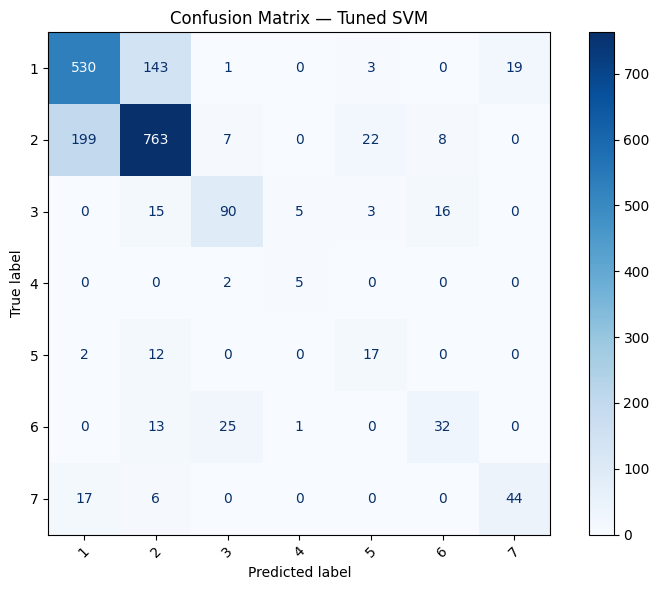

In [148]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[1,2,3,4,5,6,7])
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix — Tuned SVM")
plt.tight_layout()
plt.show()

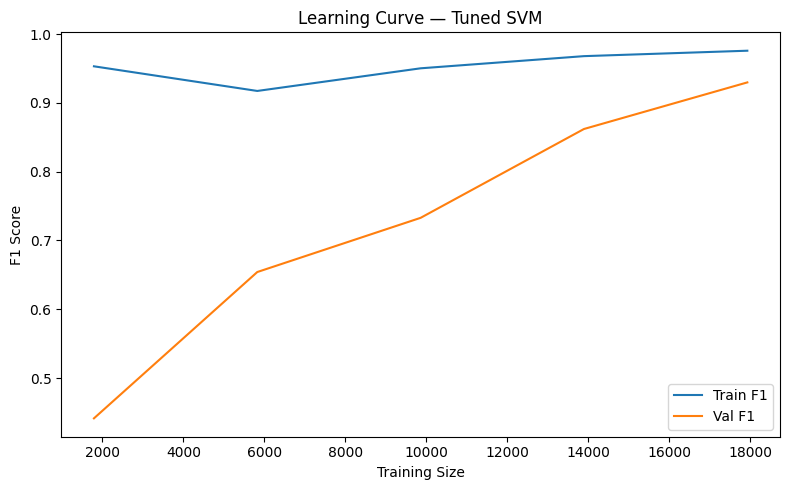

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    grid.best_estimator_,
    X_train_pca, y_train,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train F1')
plt.plot(train_sizes, val_scores.mean(axis=1),   label='Val F1')
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve — Tuned SVM")
plt.legend()
plt.tight_layout()
plt.show()